# Module 4 Data Sovereignty Framework
Demonstrates the governance layer actually enforcing access, not just
describing it. Aligned with OCAP(R), the CARE Principles, and Local
Contexts TK Labels. See `daear_toolkit.governance` for the implementation.

**No real Tribal or culturally-sensitive data is used in this notebook.**
Everything below is a synthetic stand-in dataset used only to demonstrate
the access-control mechanism.

In [ ]:
import daear_toolkit as dt
from daear_toolkit import data_access, governance, indicators, viz
import matplotlib.pyplot as plt

REGION = dt.POUDRE_CAMERON_PEAK
BBOX = REGION.bbox

# A landscape resilience layer, same kind of output as
# soil-watershed-intelligence Module 3 but treated here as a governed product.
burn = data_access.get_burn_severity(BBOX, fire_year=REGION.fire_year)
terrain = data_access.get_terrain(BBOX)
soil = data_access.get_soil_properties(BBOX)
erosion = indicators.erosion_susceptibility(terrain["slope_deg"], burn, soil["runoff_potential"])
resilience = indicators.watershed_resilience_index(erosion, soil["runoff_potential"])

## Define governance records for three example products at three access tiers

In [ ]:
public_record = governance.GovernanceRecord(
    title="Watershed-level resilience trend (aggregated)",
    steward="Daear Consulting (public release)",
    access_tier=governance.AccessTier.PUBLIC,
    care_notes="Aggregated to watershed level; no site-specific information exposed.",
)

community_record = governance.GovernanceRecord(
    title="Sub-watershed resilience map, full resolution",
    steward="Example Tribal Natural Resources Department",
    access_tier=governance.AccessTier.COMMUNITY,
    care_notes="Shared under a data-sharing agreement with the steward Nation; "
                "not for public redistribution without steward approval.",
    ocap_notes="Ownership and control remain with the steward Nation; Daear holds "
                "a processing/possession role under contract.",
)

restricted_record = governance.GovernanceRecord(
    title="Site-level fire history near culturally-sensitive locations",
    steward="Example Tribal Historic Preservation Office",
    access_tier=governance.AccessTier.RESTRICTED,
    care_notes="Precise locations are never released outside the steward office, "
                "including to Daear's own general-purpose dashboards.",
    local_contexts_notice="TK Label: TK Attribution (example placeholder)",
)

for r in (public_record, community_record, restricted_record):
    print(f"- {r.title}\n    tier={r.access_tier.value}  steward={r.steward}\n")

- Watershed-level resilience trend (aggregated)
    tier=public  steward=Daear Consulting (public release)

- Sub-watershed resilience map, full resolution
    tier=community  steward=Example Tribal Natural Resources Department

- Site-level fire history near culturally-sensitive locations
    tier=restricted  steward=Example Tribal Historic Preservation Office



## Enforce access: three requests, three outcomes

In [ ]:
# 1. A public-tier requester asking for the RESTRICTED product: denied.
try:
    governance.gated_release(restricted_record, governance.AccessTier.PUBLIC, payload=resilience)
except governance.AccessDeniedError as e:
    print(f"DENIED (as expected):\n  {e}\n")

# 2. A community-tier requester (ex. the steward Nation's own staff) asking
#    for the COMMUNITY product: served.
served = governance.gated_release(community_record, governance.AccessTier.COMMUNITY, payload=resilience)
print(f"SERVED: community-tier requester received the full-resolution layer "
      f"(shape={served.shape})\n")

# 3. The RESTRICTED product is never served at full resolution to anyone
#    outside the steward office, but a PUBLIC-safe aggregate version can be
#    derived and released instead.
public_safe = governance.aggregate_to_public(resilience, coarsen_factor=10)
released = governance.gated_release(public_record, governance.AccessTier.PUBLIC, payload=public_safe)
print(f"SERVED (aggregated): public-tier requester received a "
      f"{released.shape} coarsened layer instead of the "
      f"{resilience.shape} full-resolution product.")

DENIED (as expected):
  'Site-level fire history near culturally-sensitive locations' requires restricted-tier access; requester has public-tier access. Steward of record: Example Tribal Historic Preservation Office.

SERVED: community-tier requester received the full-resolution layer (shape=(151, 200))

SERVED (aggregated): public-tier requester received a (15, 20) coarsened layer instead of the (151, 200) full-resolution product.


## Visual: what public release looks like vs. what stays restricted

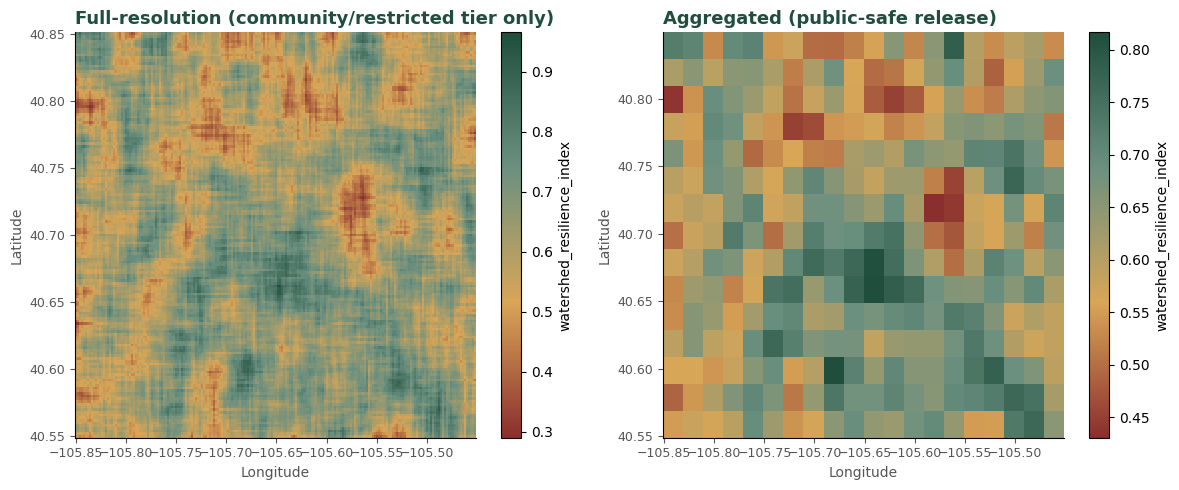

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
viz.plot_raster(resilience, title="Full-resolution (community/restricted tier only)", ax=axes[0])
viz.plot_raster(public_safe, title="Aggregated (public-safe release)", ax=axes[1])
plt.tight_layout()
plt.savefig("../outputs/04_public_vs_restricted.png", dpi=150)
plt.show()

## Summary

This is the mechanism, not just the policy: `GovernanceRecord` +
`gated_release` + `aggregate_to_public` enforce the two-track public/Tribal
data pattern in code. The same three functions gate every other repo's
sensitive outputs i.e. `tribal-wildfire-intelligence` is simply where that
enforcement is demonstrated explicitly.
